In [1]:
%pip install pandas matplotlib seaborn scikit-learn numpy requests httpx

In [56]:
%pip install geopy plotly

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import httpx
import os
import json
import requests

from geopy.geocoders import Nominatim

In [42]:
def fetch_weather(lat, lon, forecast_days=14):
    url = "https://api.open-meteo.com/v1/forecast"

    hourly_fields = [
        "temperature_2m",
        "relative_humidity_2m",
        "dew_point_2m",
        "apparent_temperature",
        "cloud_cover",
        "precipitation",
        "snowfall",
        "precipitation_probability",
        "rain",
        "shortwave_radiation",
        "diffuse_radiation",
    ]

    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ",".join(hourly_fields),
        "forecast_days": forecast_days,
        "timezone": "auto",
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    if "hourly" not in data:
        raise ValueError(f"Open-Meteo response missing 'hourly': {data}")

    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])

    return df

In [38]:
def geocode_location(location):
    geolocator = Nominatim(user_agent="terraseek")

    try:
        geocode_loc = geolocator.geocode(location)
        if geocode_loc:
            return geocode_loc.latitude, geocode_loc.longitude
        else:
            print(f"Could not geocode location: {location}")
            return None, None
    except Exception as e:
        print(f"Error geocoding location: {location} - {e}")
        return None, None

In [43]:
coordinates = geocode_location("Hyderabad, India")

df = fetch_weather(*coordinates)

In [44]:
df.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,cloud_cover,precipitation,snowfall,precipitation_probability,rain,shortwave_radiation,diffuse_radiation
0,2026-04-17 00:00:00,29.4,56,19.7,32.6,33,0.0,0.0,0,0.0,0.0,0.0
1,2026-04-17 01:00:00,29.0,60,20.5,32.8,51,0.0,0.0,3,0.0,0.0,0.0
2,2026-04-17 02:00:00,28.6,63,20.9,32.6,64,0.0,0.0,5,0.0,0.0,0.0
3,2026-04-17 03:00:00,28.1,64,20.7,31.9,70,0.0,0.0,5,0.0,0.0,0.0
4,2026-04-17 04:00:00,28.0,63,20.3,31.5,75,0.0,0.0,0,0.0,0.0,0.0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   time                       336 non-null    datetime64[ns]
 1   temperature_2m             336 non-null    float64       
 2   relative_humidity_2m       336 non-null    int64         
 3   dew_point_2m               336 non-null    float64       
 4   apparent_temperature       336 non-null    float64       
 5   cloud_cover                336 non-null    int64         
 6   precipitation              336 non-null    float64       
 7   snowfall                   336 non-null    float64       
 8   precipitation_probability  336 non-null    int64         
 9   rain                       336 non-null    float64       
 10  shortwave_radiation        336 non-null    float64       
 11  diffuse_radiation          336 non-null    float64       
dtypes: datet

In [46]:
df.describe()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,cloud_cover,precipitation,snowfall,precipitation_probability,rain,shortwave_radiation,diffuse_radiation
count,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0,336.000000,336.0,336.000000,336.000000
mean,2026-04-23 23:30:00.000000256,32.848512,40.101190,15.236012,34.066964,70.083333,0.024405,0.0,9.511905,0.0,283.505655,77.993155
min,2026-04-17 00:00:00,23.900000,10.000000,1.300000,27.200000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
25%,2026-04-20 11:45:00,28.600000,24.000000,12.075000,30.600000,43.000000,0.000000,0.0,1.000000,0.0,0.000000,0.000000
50%,2026-04-23 23:30:00,32.550000,36.500000,16.200000,33.150000,88.500000,0.000000,0.0,5.000000,0.0,36.500000,16.000000
75%,2026-04-27 11:15:00,37.100000,60.000000,19.700000,37.525000,100.000000,0.000000,0.0,15.000000,0.0,585.000000,145.500000
max,2026-04-30 23:00:00,41.700000,78.000000,22.500000,43.600000,100.000000,2.000000,0.0,45.000000,0.0,1041.000000,402.000000
std,NaN,4.926044,19.993474,5.070504,4.188015,35.213281,0.134051,0.0,10.278212,0.0,355.853101,96.080306


In [47]:
df.isnull().sum()

,0
time,0
temperature_2m,0
relative_humidity_2m,0
dew_point_2m,0
apparent_temperature,0
cloud_cover,0
precipitation,0
snowfall,0
precipitation_probability,0
rain,0


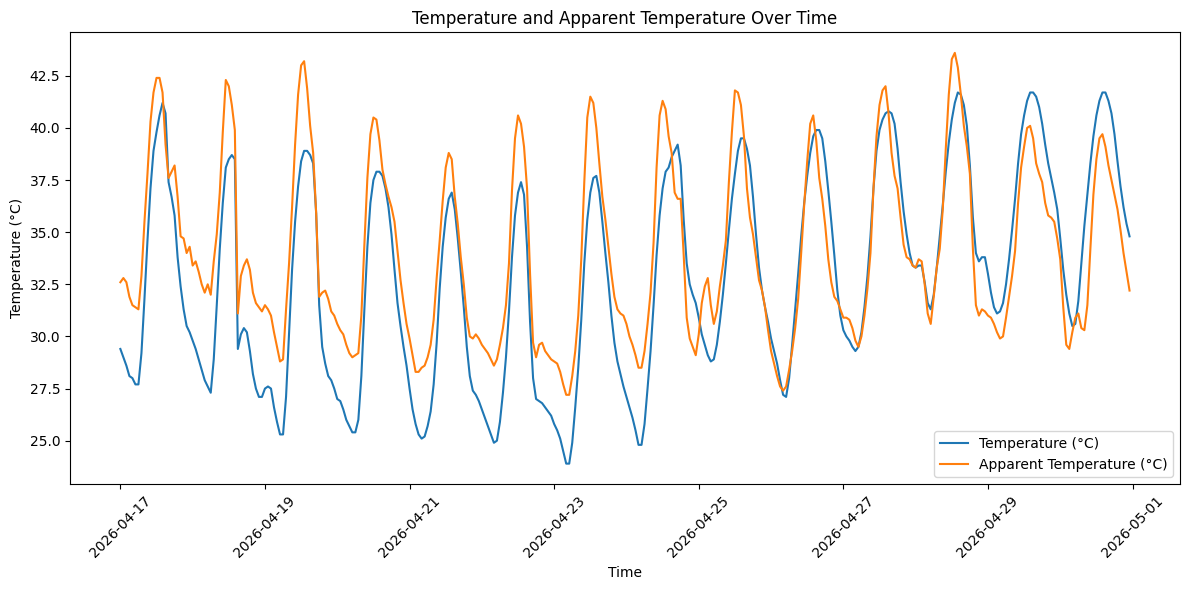

In [48]:
plt.figure(figsize=(12,6))
plt.plot(df['time'], df['temperature_2m'], label='Temperature (°C)')
plt.plot(df['time'], df['apparent_temperature'], label='Apparent Temperature (°C)')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature and Apparent Temperature Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation

Apparent temperature closely follows actual temperature with minor deviations, indicating strong correlation. This suggests it may not add significant independent predictive value.

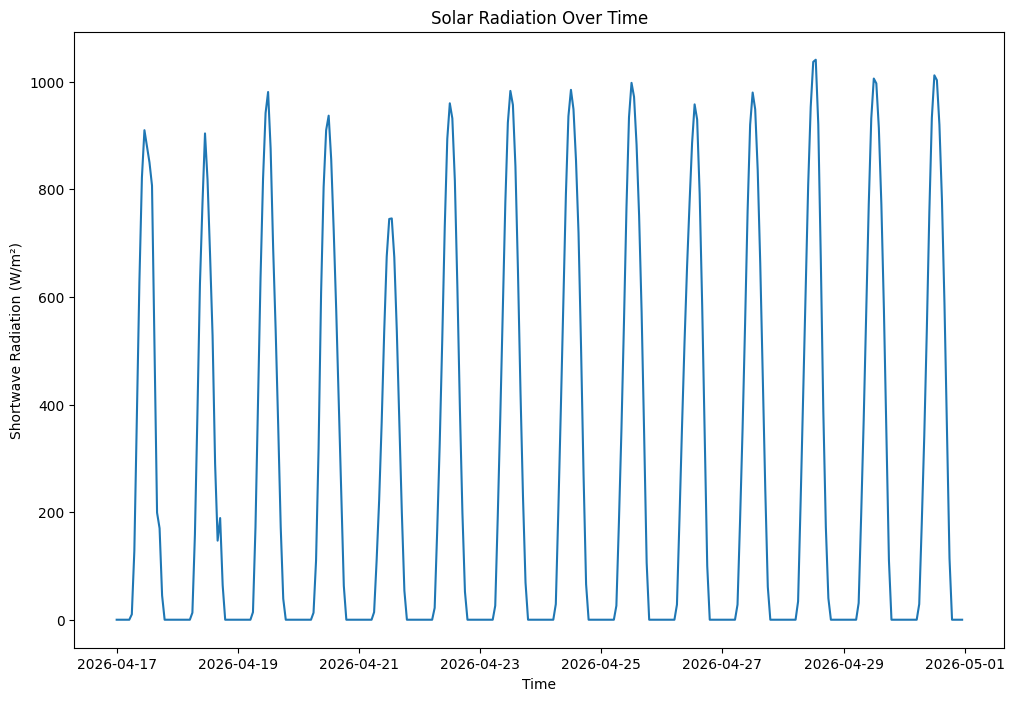

In [49]:
plt.figure(figsize=(12,8))
plt.plot(df["time"], df["shortwave_radiation"])
plt.xlabel("Time")
plt.ylabel("Shortwave Radiation (W/m²)")
plt.title("Solar Radiation Over Time")
plt.show()

Solar radiation shows a strong daily periodic pattern, with values rising sharply during daytime and dropping to zero at night. This confirms the presence of strong 24-hour seasonality, making it suitable for decomposition-based forecasting methods.

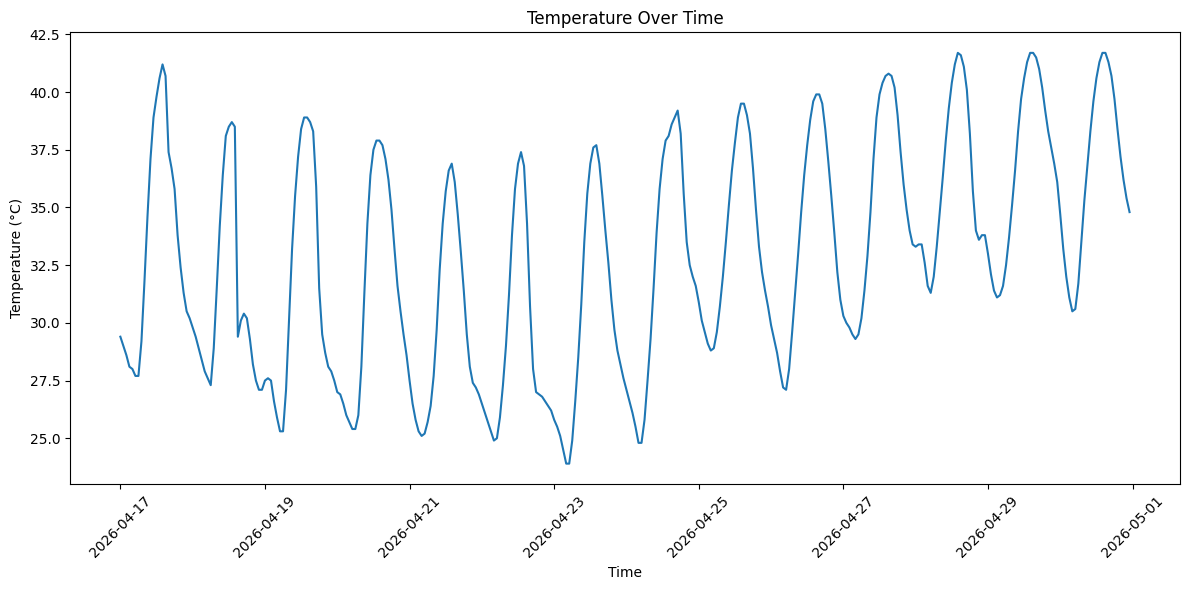

In [50]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='time', y='temperature_2m', data=df)
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Temperature exhibits smooth cyclical behavior with clear daily peaks and troughs. There is also a slight upward trend over time, indicating a combination of seasonal and trend components.

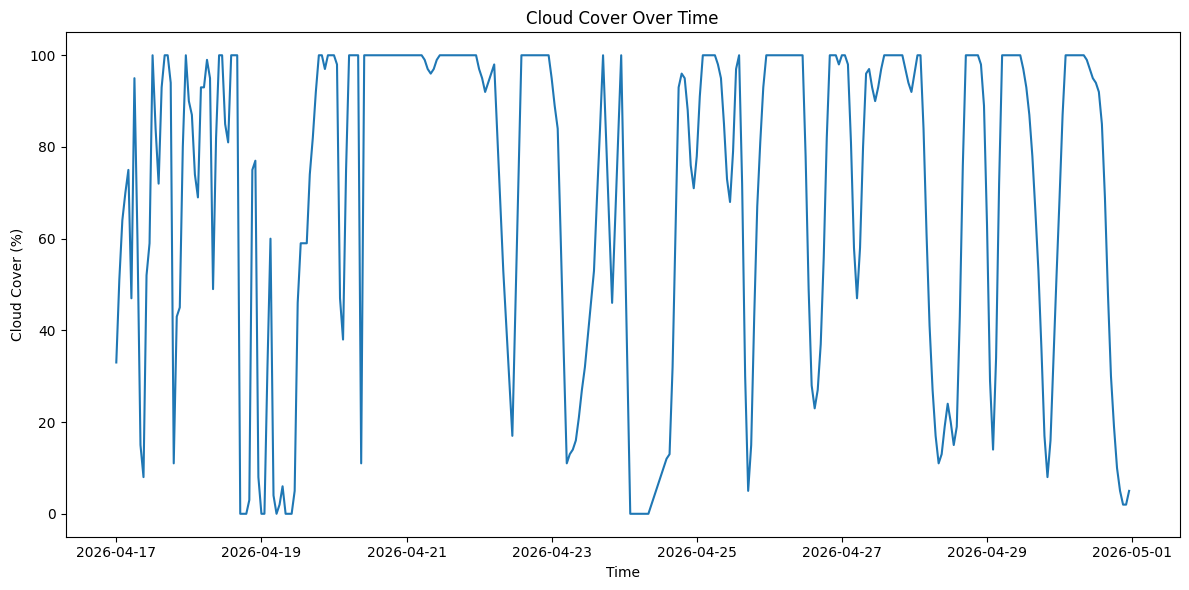

In [53]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='time', y='cloud_cover', data=df)
plt.xlabel('Time')
plt.ylabel('Cloud Cover (%)')
plt.title('Cloud Cover Over Time')
plt.tight_layout()
plt.show()

Cloud cover shows highly irregular and abrupt changes, indicating a noisy and less predictable pattern. However, it is expected to strongly influence solar radiation, making it an important explanatory feature.

In [54]:
df.corr(numeric_only=True)

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,cloud_cover,precipitation,snowfall,precipitation_probability,rain,shortwave_radiation,diffuse_radiation
temperature_2m,1.000000,-0.941578,-0.771187,0.880866,-0.046145,-0.035295,NaN,-0.140357,NaN,0.700318,0.582679
relative_humidity_2m,-0.941578,1.000000,0.888240,-0.701019,-0.010807,0.064009,NaN,0.125006,NaN,-0.545476,-0.460825
dew_point_2m,-0.771187,0.888240,1.000000,-0.436675,0.006228,0.116313,NaN,0.190312,NaN,-0.339531,-0.253775
apparent_temperature,0.880866,-0.701019,-0.436675,1.000000,-0.132394,-0.017542,NaN,-0.108960,NaN,0.836468,0.683407
cloud_cover,-0.046145,-0.010807,0.006228,-0.132394,1.000000,0.120921,NaN,0.300839,NaN,-0.112855,0.124542
precipitation,-0.035295,0.064009,0.116313,-0.017542,0.120921,1.000000,NaN,0.291404,NaN,0.005097,0.115548
snowfall,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precipitation_probability,-0.140357,0.125006,0.190312,-0.108960,0.300839,0.291404,NaN,1.000000,NaN,-0.191355,-0.004469
rain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shortwave_radiation,0.700318,-0.545476,-0.339531,0.836468,-0.112855,0.005097,NaN,-0.191355,NaN,1.000000,0.841147


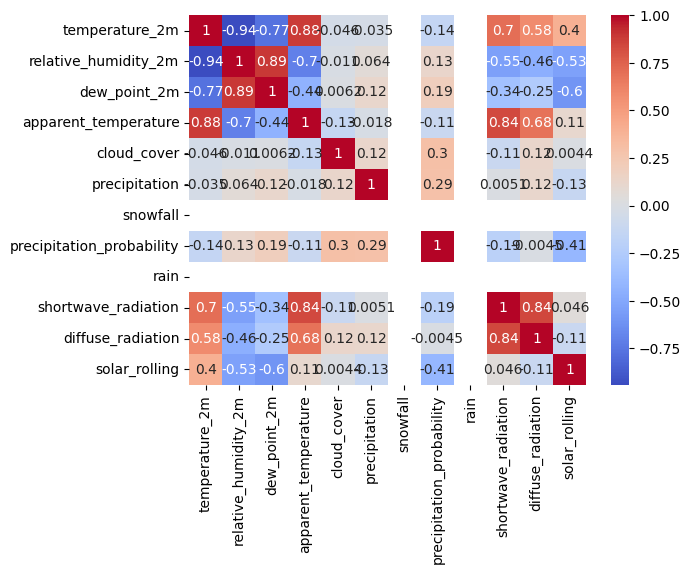

In [64]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

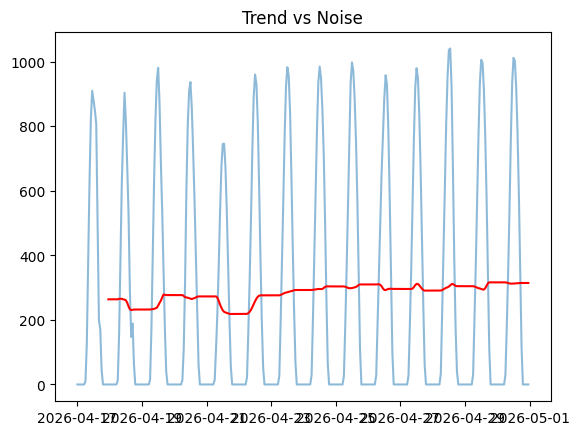

In [62]:
df["solar_rolling"] = df["shortwave_radiation"].rolling(24).mean()

plt.plot(df["time"], df["shortwave_radiation"], alpha=0.5)
plt.plot(df["time"], df["solar_rolling"], color="red")
plt.title("Trend vs Noise")
plt.show()

In [63]:
solar_df = df[["time", "shortwave_radiation"]].rename(
    columns={"time": "ds", "shortwave_radiation": "y"}
)

solar_df.head()

,ds,y
0,2026-04-17 00:00:00,0.0
1,2026-04-17 01:00:00,0.0
2,2026-04-17 02:00:00,0.0
3,2026-04-17 03:00:00,0.0
4,2026-04-17 04:00:00,0.0


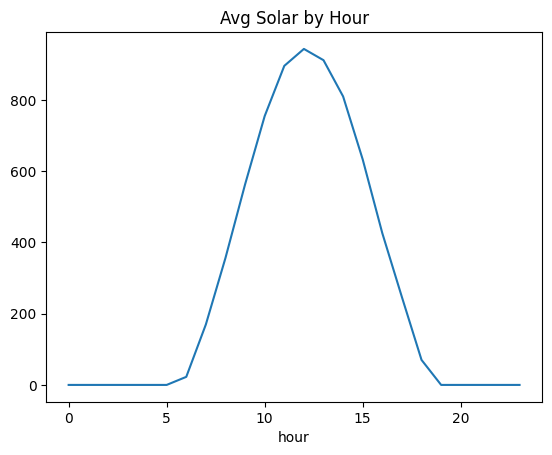

In [65]:
df["hour"] = df["time"].dt.hour

df.groupby("hour")["shortwave_radiation"].mean().plot()
plt.title("Avg Solar by Hour")
plt.show()